In [1]:
import torch
import torchvision

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("mps available:", torch.backends.mps.is_available())

torch: 2.13.0
torchvision: 0.28.0
mps available: True


In [2]:
import pandas as pd
import torch

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

df = pd.read_csv("../outputs/final_split.csv")

print("device:", device)
print(df["split"].value_counts())
print("classes:", df["label"].nunique())
print("total:", len(df))

device: mps
split
train         3125
validation     684
test           684
Name: count, dtype: int64
classes: 18
total: 4493


In [3]:
# buat preprocessing yang mempertahankan aspect ratio

from PIL import ImageOps
from torchvision import transforms

IMAGE_SIZE = 224

class PadToSquare:
    def __call__(self, image):
        width, height = image.size
        max_side = max(width, height)

        pad_left = (max_side - width) // 2
        pad_right = max_side - width - pad_left
        pad_top = (max_side - height) // 2
        pad_bottom = max_side - height - pad_top

        return ImageOps.expand(
            image,
            border=(pad_left, pad_top, pad_right, pad_bottom),
            fill="white"
        )

base_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    PadToSquare(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

print(base_transform)

Compose(
    Lambda()
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


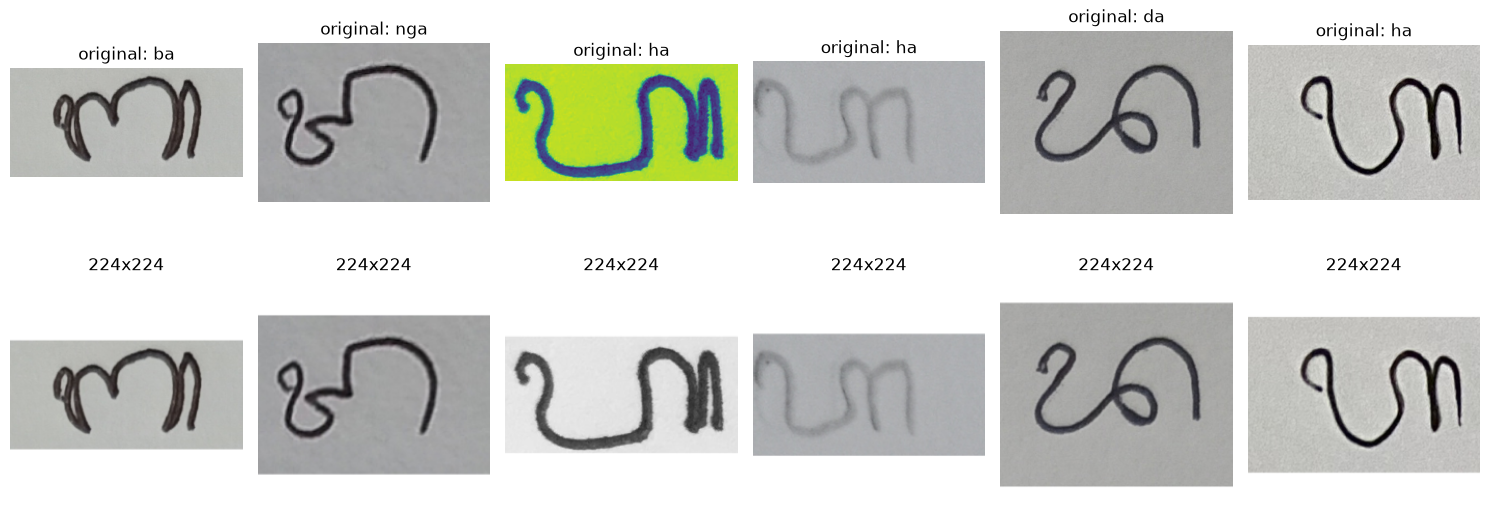

In [4]:
# visual check preprocessing
import matplotlib.pyplot as plt
from PIL import Image
import random

sample_rows = df.sample(6, random_state=42)

fig, axes = plt.subplots(2, 6, figsize=(15, 6))

for i, (_, row) in enumerate(sample_rows.iterrows()):
    img = Image.open(row["path"])

    # original
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'original: {row["label"]}')
    axes[0, i].axis("off")

    # transformed
    transformed = base_transform(img)
    transformed_img = transformed.permute(1, 2, 0)

    axes[1, i].imshow(transformed_img)
    axes[1, i].set_title("224x224")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [5]:
from collections import Counter
from PIL import Image

modes = Counter()

for _, row in df.iterrows():
    with Image.open(row["path"]) as img:
        modes[img.mode] += 1

print(modes)

Counter({'RGB': 4026, 'L': 467})


In [6]:
class_names = sorted(df["label"].unique())

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

print(class_to_idx)
print("total classes:", len(class_to_idx))

{'ba': 0, 'ca': 1, 'da': 2, 'ga': 3, 'ha': 4, 'ja': 5, 'ka': 6, 'la': 7, 'ma': 8, 'na': 9, 'nga': 10, 'nya': 11, 'pa': 12, 'ra': 13, 'sa': 14, 'ta': 15, 'wa': 16, 'ya': 17}
total classes: 18


buat custom dataset

sekarang kita bikin Dataset PyTorch yang membaca:

path image
label
transform preprocessing

buat cell baru:

In [7]:
from torch.utils.data import Dataset
from PIL import Image

class BalineseHandwritingDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image = Image.open(row["path"])
        label = class_to_idx[row["label"]]

        if self.transform:
            image = self.transform(image)

        return image, label


train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "validation"].copy()
test_df = df[df["split"] == "test"].copy()

train_dataset = BalineseHandwritingDataset(
    train_df,
    transform=base_transform
)

val_dataset = BalineseHandwritingDataset(
    val_df,
    transform=base_transform
)

test_dataset = BalineseHandwritingDataset(
    test_df,
    transform=base_transform
)

print("train:", len(train_dataset))
print("validation:", len(val_dataset))
print("test:", len(test_dataset))

train: 3125
validation: 684
test: 684


In [ ]:
# bikin dataloader + cek satu batch
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

images, labels = next(iter(train_loader))

print("images shape:", images.shape)
print("labels shape:", labels.shape)
print("min pixel:", images.min().item())
print("max pixel:", images.max().item())

images shape: torch.Size([32, 3, 224, 224])
labels shape: torch.Size([32])
min pixel: 0.0
max pixel: 1.0


In [9]:
# buat baseline cnn

import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=18):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


model = BaselineCNN(num_classes=18).to(device)

total_params = sum(p.numel() for p in model.parameters())

print(model)
print("\ntotal parameters:", total_params)
print("device:", next(model.parameters()).device)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Linear(in_features=128, out_features=18, bias=True)
)

total para

In [10]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)
loss = criterion(outputs, labels)

print("output shape:", outputs.shape)
print("label shape:", labels.shape)
print("loss:", loss.item())

output shape: torch.Size([32, 18])
label shape: torch.Size([32])
loss: 2.8683547973632812


In [11]:
# define training loop

import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [12]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    loss = running_loss / total
    acc = correct / total

    return loss, acc

## 6. Baseline CNN Training

A simple CNN is trained from scratch as the baseline model for the 18-class Balinese handwriting classification task.

The purpose of this baseline is to establish an initial performance benchmark before experimenting with more advanced architectures such as MobileNetV3 or EfficientNet-B0.

Training is monitored using:
- training loss
- training accuracy
- validation loss
- validation accuracy

The model with the highest validation accuracy is saved for later evaluation.

In [13]:
# train baseline

import torch
import torch.optim as optim

# reset model supaya training baseline reproducible
torch.manual_seed(42)

model = BaselineCNN(num_classes=18).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 15

history = []
best_val_acc = 0.0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(
            model.state_dict(),
            "../outputs/baseline_cnn_best.pt"
        )

    print(
        f"epoch {epoch+1:02d}/{EPOCHS} | "
        f"train loss: {train_loss:.4f} | "
        f"train acc: {train_acc:.4f} | "
        f"val loss: {val_loss:.4f} | "
        f"val acc: {val_acc:.4f}"
    )

print(f"\nbest validation accuracy: {best_val_acc:.4f}")

epoch 01/15 | train loss: 2.8386 | train acc: 0.0960 | val loss: 2.7882 | val acc: 0.1067
epoch 02/15 | train loss: 2.7677 | train acc: 0.1274 | val loss: 2.7464 | val acc: 0.1594
epoch 03/15 | train loss: 2.7371 | train acc: 0.1235 | val loss: 2.7702 | val acc: 0.1199
epoch 04/15 | train loss: 2.7060 | train acc: 0.1402 | val loss: 2.7560 | val acc: 0.1126
epoch 05/15 | train loss: 2.6739 | train acc: 0.1514 | val loss: 2.6528 | val acc: 0.1725
epoch 06/15 | train loss: 2.6349 | train acc: 0.1722 | val loss: 2.6130 | val acc: 0.1827
epoch 07/15 | train loss: 2.6042 | train acc: 0.1862 | val loss: 3.6893 | val acc: 0.0629
epoch 08/15 | train loss: 2.5723 | train acc: 0.1917 | val loss: 2.6353 | val acc: 0.1491
epoch 09/15 | train loss: 2.5423 | train acc: 0.2099 | val loss: 2.7302 | val acc: 0.1199
epoch 10/15 | train loss: 2.5112 | train acc: 0.2186 | val loss: 2.7152 | val acc: 0.1637
epoch 11/15 | train loss: 2.4742 | train acc: 0.2298 | val loss: 2.4487 | val acc: 0.2310
epoch 12/1

## 7. Baseline CNN Training Analysis

The baseline CNN showed that the model was able to learn patterns from the dataset, but its performance remained limited.

The best validation accuracy was 23.1%, while training accuracy reached 28.2% after 15 epochs. Since both training and validation performance remained relatively low, the model appears to be underfitting rather than overfitting.

The baseline will be used as a reference point before experimenting with a stronger pretrained architecture.

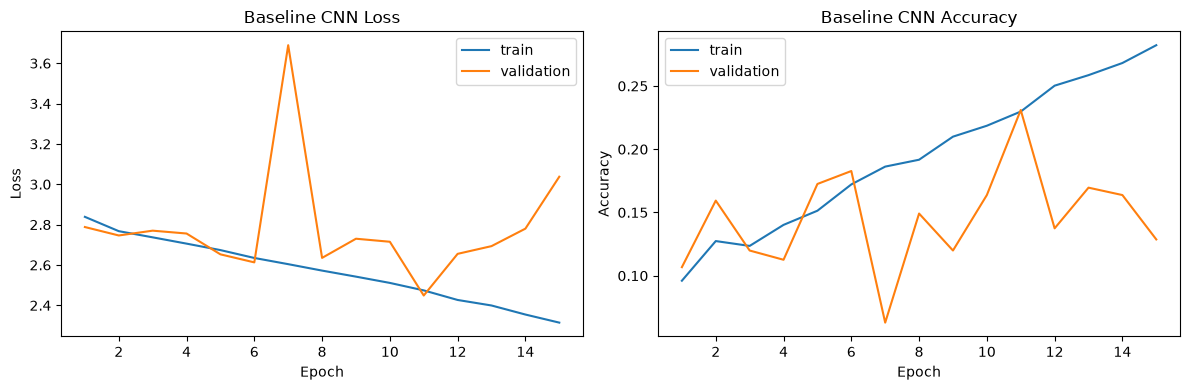

In [14]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="train"
)

axes[0].plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="validation"
)

axes[0].set_title("Baseline CNN Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()


# Accuracy
axes[1].plot(
    history_df["epoch"],
    history_df["train_acc"],
    label="train"
)

axes[1].plot(
    history_df["epoch"],
    history_df["val_acc"],
    label="validation"
)

axes[1].set_title("Baseline CNN Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

grafiknya mengonfirmasi analisis tadi:

* train loss turun konsisten → model memang belajar
* train accuracy terus naik
* validation sangat fluktuatif
* best val accuracy cuma **23.1%**
* jadi baseline ini **underfitting + generalization-nya lemah**

ini sudah cukup sebagai baseline. kita **jangan utak-atik custom cnn ini dulu**. sekarang masuk ke **initial iteration: transfer learning dengan MobileNetV3**.



## 8. Initial Iteration — MobileNetV3 Transfer Learning

The baseline CNN achieved a best validation accuracy of 23.1%, indicating that the simple model was not expressive enough for the handwriting classification task.

As the first model iteration, MobileNetV3-Large with ImageNet pretrained weights is used through transfer learning.

MobileNetV3 is selected because it:
- provides a stronger pretrained visual representation
- is designed with mobile deployment efficiency in mind
- can later be converted to Core ML for on-device inference

For the first stage, the pretrained feature extractor is frozen and only the final classifier is trained for the 18 Balinese character classes.

The test set remains untouched during model development.

In [15]:
from torchvision import transforms

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

mobilenet_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    PadToSquare(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

print(mobilenet_transform)

Compose(
    Lambda()
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
